<a href="https://colab.research.google.com/github/guebin/DL2026/blob/master/posts/08wk.ipynb"><img src="https://colab.research.google.com/assets/colab-badge.svg" style="text-align: left"></a>

# 1. 강의영상

{{<https://youtu.be/playlist?list=PLQqh36zP38-yzw3eNUkPA8DuflmiLzXi4&si=cpr1BxpgPoDED99a>}}

# 2. Imports

In [32]:
import torch
import torchvision
import matplotlib.pyplot as plt

In [ ]:
plt.rcParams['figure.figsize'] = (4.5,3.0)

# 3. MNIST 3/7

- 흑백으로 된 숫자이미지자료

## A. 예비학습

`-` 흑백이미지의 이해

In [ ]:
img = torch.tensor([[255,0,0],[255,0,0],[0,100,255]])
img

tensor([[255,   0,   0],
        [255,   0,   0],
        [  0, 100, 255]])

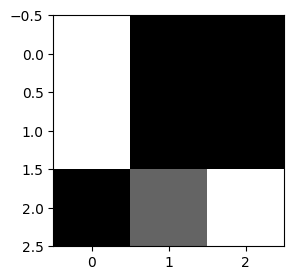

In [ ]:
plt.imshow(img,cmap="gray")

In [ ]:
img.shape # (3,3)의 픽셀을 가진 흑백이미지로 해석할 수 있음.

torch.Size([3, 3])

`-` 빛의 3원색: ref - <https://ko.wikipedia.org/wiki/%EC%9B%90%EC%83%89>

![](https://upload.wikimedia.org/wikipedia/commons/thumb/e/e0/Synthese%2B.svg/500px-Synthese%2B.svg.png)

- 우리가 보는 색상은 모두 (빨강,녹색,파랑)의 조합으로 나타낼 수 있음.
- (빨강,녹색,파랑)을 RGB라고 흔히 부름

`-` 칼라이미지의 이해

tensor([[255, 255, 255, 255],
        [255, 255, 255, 255],
        [  0,   0,   0,   0],
        [  0,   0,   0,   0]])
tensor([[  0,   0,   0,   0],
        [255, 255, 255,   0],
        [255, 255, 255,   0],
        [255, 255, 255,   0]])
tensor([[  0,   0,   0,   0],
        [  0, 255, 255, 255],
        [  0, 255, 255, 255],
        [  0, 255, 255, 255]])


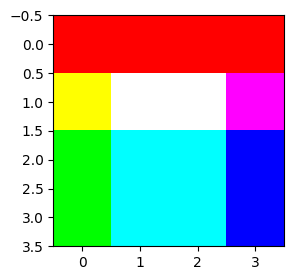

In [ ]:
r = torch.tensor([[255,255,255,255],[255,255,255,255],[0,0,0,0],[0,0,0,0]])
g = torch.tensor([[0,0,0,0],[255,255,255,0],[255,255,255,0],[255,255,255,0]])
b = torch.tensor([[0,0,0,0],[0,255,255,255],[0,255,255,255],[0,255,255,255]])
print(r)
print(g)
print(b)
img = torch.stack([r,g,b],axis=-1)
plt.imshow(img)

In [ ]:
img.shape # (4,4)픽셀을 가진 칼라이미지로 해석

torch.Size([4, 4, 3])

`-` `plt.imshow(...)`에서 `...`의 자료형이 정수(int)이면 빛의 밝기범위를 0~255로 자동인식하고 `...`의 자료형이 소수(float)이면 빛의 밝기범위를 0~1사이의 값으로 인식함.

tensor([[1, 1, 1, 1],
        [1, 1, 1, 1],
        [0, 0, 0, 0],
        [0, 0, 0, 0]])
tensor([[0, 0, 0, 0],
        [1, 1, 1, 0],
        [1, 1, 1, 0],
        [1, 1, 1, 0]])
tensor([[0, 0, 0, 0],
        [0, 1, 1, 1],
        [0, 1, 1, 1],
        [0, 1, 1, 1]])


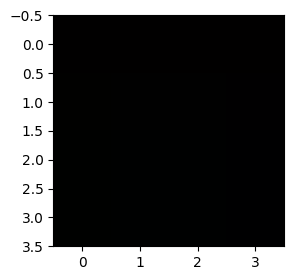

In [ ]:
r = torch.tensor([[1,1,1,1],[1,1,1,1],[0,0,0,0],[0,0,0,0]])
g = torch.tensor([[0,0,0,0],[1,1,1,0],[1,1,1,0],[1,1,1,0]])
b = torch.tensor([[0,0,0,0],[0,1,1,1],[0,1,1,1],[0,1,1,1]])
print(r)
print(g)
print(b)
img = torch.stack([r,g,b],axis=-1)
plt.imshow(img)

tensor([[1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]])
tensor([[0., 0., 0., 0.],
        [1., 1., 1., 0.],
        [1., 1., 1., 0.],
        [1., 1., 1., 0.]])
tensor([[0., 0., 0., 0.],
        [0., 1., 1., 1.],
        [0., 1., 1., 1.],
        [0., 1., 1., 1.]])


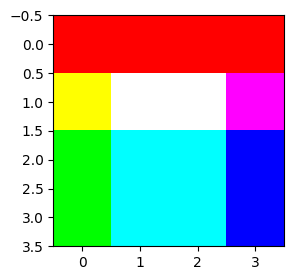

In [ ]:
r = torch.tensor([[1,1,1,1],[1,1,1,1],[0,0,0,0],[0,0,0,0]]).float()
g = torch.tensor([[0,0,0,0],[1,1,1,0],[1,1,1,0],[1,1,1,0]]).float()
b = torch.tensor([[0,0,0,0],[0,1,1,1],[0,1,1,1],[0,1,1,1]]).float()
print(r)
print(g)
print(b)
img = torch.stack([r,g,b],axis=-1)
plt.imshow(img)

## B. 데이터

`-` 데이터정리코드

In [ ]:
train_dataset = torchvision.datasets.MNIST(root='./data',train=True,download=True)
to_tensor = torchvision.transforms.ToTensor()
X3 = torch.stack([to_tensor(Xi) for Xi, yi in train_dataset if yi==3],axis=0)
X7 = torch.stack([to_tensor(Xi) for Xi, yi in train_dataset if yi==7],axis=0)

torch.Size([6131, 1, 28, 28])


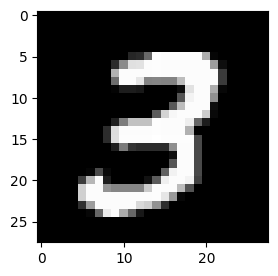

In [ ]:
print(X3.shape) # 숫자3이 손글씨로 적힌 6131개의 이미지, 이미지의 픽셀은 (28,28)
plt.imshow(X3[0,:,:,:].reshape(28,28),cmap="gray")

torch.Size([6265, 1, 28, 28])


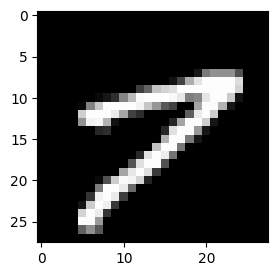

In [ ]:
print(X7.shape) # 숫자7이 손글씨로 적힌 6265개의 이미지, 이미지의 픽셀은 (28,28)
plt.imshow(X7[-1,:,:,:].reshape(28,28),cmap="gray")

In [ ]:
X = torch.concat([X3,X7],axis=0)
X.shape

torch.Size([12396, 1, 28, 28])

In [ ]:
Y = torch.tensor([0]*6131 + [1]*6265).reshape(-1,1).float() # 숫자3이면 Yi=0, 숫자7이면 Yi=1로 생각하자.

In [ ]:
X.shape, Y.shape

(torch.Size([12396, 1, 28, 28]), torch.Size([12396, 1]))

`-` 우리가하고싶은것: ${\bf X}:(n,1,28,28) \to {\bf Y}:(n,1)$ 인 규칙을 알아내고 싶음. $\to$ 그렇지만 우리는 이런걸 배운적이 없는데? $\to$ ${\bf X}:(n,784) \to {\bf Y}:(n,1)$ 인 규칙을 학습하자!!

In [ ]:
X = X.reshape(-1,784)

In [ ]:
X.shape, Y.shape

(torch.Size([12396, 784]), torch.Size([12396, 1]))

## C. 학습

In [ ]:
net = torch.nn.Sequential(
    torch.nn.Linear(in_features=784,out_features=32), # 784->32
    torch.nn.ReLU(), # 32 -> 32
    torch.nn.Linear(in_features=32,out_features=1),
    torch.nn.Sigmoid()
)
loss_fn = torch.nn.BCELoss()
optimizer = torch.optim.Adam(net.parameters())
#---#
for epoch in range(200):
    # step1
    Yhat = net(X)
    # step2
    loss = loss_fn(Yhat,Y)
    # step3
    loss.backward()
    # step4
    optimizer.step()
    optimizer.zero_grad()

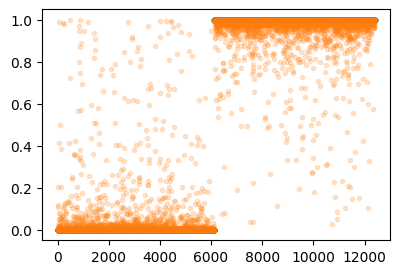

In [ ]:
plt.plot(Y,'.')
plt.plot(net(X).data,'.',alpha=0.2)

In [ ]:
(Y == (net(X).data > 0.5).float()).sum() / 12396

tensor(0.9895)

`-` 결과가 아쉬워서 좀 더 돌려보면

In [ ]:
for epoch in range(200):
    # step1
    Yhat = net(X)
    # step2
    loss = loss_fn(Yhat,Y)
    # step3
    loss.backward()
    # step4
    optimizer.step()
    optimizer.zero_grad()

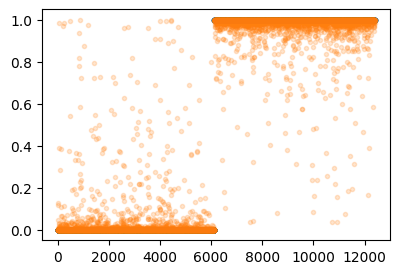

In [ ]:
plt.plot(Y,'.')
plt.plot(net(X).data,'.',alpha=0.2)

In [ ]:
(Y == (net(X).data > 0.5).float()).sum() / 12396

tensor(0.9927)

# 4. 오버피팅 (시벤코정리의 이면)

`-` 언뜻 생각하면 "시벤코정리는 무적인가?" 하는 생각이 든다.

## A. 오버피팅

`-` 오버피팅?

- 위키: In mathematical modeling, overfitting is the production of an analysis that corresponds too closely or exactly to a particular set of data, and may therefore fail to fit to additional data or predict future observations reliably. (수학적인 모델링에서 과적합이란 "어떤 모델이 주어진 데이터에 너무 꼭 맞춰져 있어서, 새로운 데이터 미래의 결과를 잘 예측하지 못할수 있는 상태"를 의미한다.)
- 통계학과는 "데이터=언더라잉스트럭처+오차항"의 관점에서 봄. 모델은 언더라잉스트럭처를 적합해야함. 그런데 만약에 모델이 오차항을 적합하고 있으면 그건 오버피팅이라 부름.

## B. 오버피팅의 예시

`-` 시벤코정리: $m$이 매우 클때

- ${\bf X}_{n\times 784} \overset{linr}{\to} {\bf U}^{(1)}_{n\times m} \overset{relu}{\to} {\bf V}^{(1)}_{n\times m} \overset{linr}{\to} {\bf U}^{(2)}_{n\times 1}\overset{sig}{\to} {\bf V}^{(2)}_{n\times 1}=\hat{\bf Y}_{n\times 1}$
- ${\bf X}_{n\times 1} \overset{linr}{\to} {\bf U}_{n\times m} \overset{relu}{\to} {\bf V}_{n\times m} \overset{linr}{\to}\hat{\bf Y}_{n\times 1}$

이러한 종류의 네트워크는 거의 무엇이듯 맞출 수 있다고 생각할 수 있다.

`-` 그런데 종종 맞추지 말아야 할 것도 맞춘다.

`-` 아래와 같은 모델을 가정하자. (지금은 박혜원씨처럼 관측하는 상태가 아니고 신처럼 데이터를 만드는 상황)

$$\text{model}: y_i = (0 \times x_i) + \epsilon_i, \quad \epsilon_i \sim N(0,0.01^2)$$

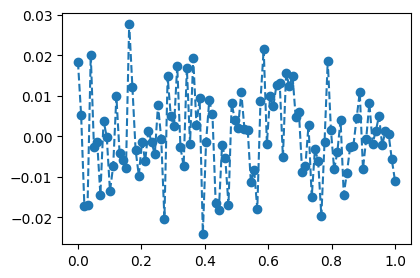

In [ ]:
torch.manual_seed(5)
X = torch.linspace(0,1,100).reshape(100,1)
Y = X*0 + torch.randn(100).reshape(100,1)*0.01
plt.plot(X,Y,'--o')

In [ ]:
torch.manual_seed(1)
net = torch.nn.Sequential(
    torch.nn.Linear(1,512),
    torch.nn.ReLU(),
    torch.nn.Linear(512,1)
)
loss_fn = torch.nn.MSELoss()
optimizer = torch.optim.Adam(net.parameters())
#---#
for epoch in range(1000):
    # step1
    Yhat = net(X)
    # step2
    loss = loss_fn(Yhat,Y)
    # step3
    loss.backward()
    # step4
    optimizer.step()
    optimizer.zero_grad()


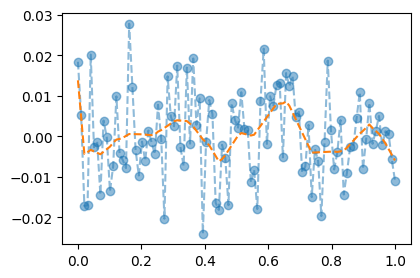

In [ ]:
plt.plot(X,Y,'--o',alpha=0.5)
plt.plot(X,net(X).data,'--')

## C. 오버피팅이라는 증거

In [ ]:
torch.manual_seed(5)
Xall = torch.linspace(0,1,100).reshape(100,1)
Yall = Xall*0 + torch.randn(100).reshape(100,1)*0.01
X = Xall[:80,:]
Y = Yall[:80,:]
XX = Xall[80:,:]
YY = Yall[80:,:]

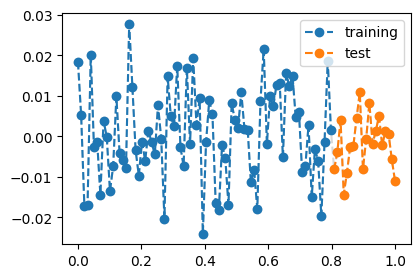

In [ ]:
plt.plot(Xall,Yall,'--o',color="gray",alpha=0.3)
plt.plot(X,Y,'--o',label="training")
plt.plot(XX,YY,'--o',label="test")
plt.legend()

`-` train만 학습

In [ ]:
torch.manual_seed(1)
net = torch.nn.Sequential(
    torch.nn.Linear(1,512),
    torch.nn.ReLU(),
    torch.nn.Linear(512,1)
)
loss_fn = torch.nn.MSELoss()
optimizer = torch.optim.Adam(net.parameters())
#---#
for epoch in range(1000):
    # step1
    Yhat = net(X)
    # step2
    loss = loss_fn(Yhat,Y)
    # step3
    loss.backward()
    # step4
    optimizer.step()
    optimizer.zero_grad()


`-` 적합결과 관찰

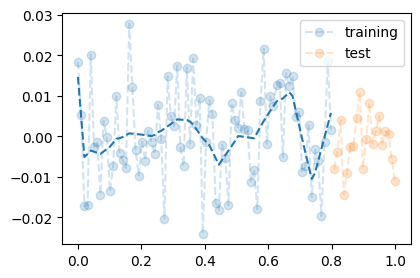

In [ ]:
plt.plot(X,Y,'--o',label="training",alpha=0.2)
plt.plot(XX,YY,'--o',label="test",alpha=0.2)
plt.plot(X,net(X).data,'--',color="C0")
plt.legend()

- training에서는 그럭저럭 잘맞춤

`-` 새로운데이터(예측)

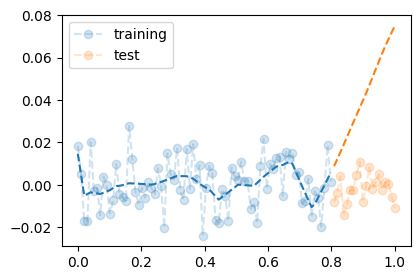

In [ ]:
plt.plot(X,Y,'--o',label="training",alpha=0.2)
plt.plot(XX,YY,'--o',label="test",alpha=0.2)
plt.plot(X,net(X).data,'--',color="C0")
plt.plot(XX,net(XX).data,'--',color="C1")
plt.legend()

- training에서는 그럭저럭 괜찮았는데, test에서는 망했다.

In [ ]:
loss_fn(net(X),Y)

tensor(9.5141e-05, grad_fn=<MseLossBackward0>)

In [ ]:
loss_fn(net(X)*0,Y)

tensor(0.0001, grad_fn=<MseLossBackward0>)

## D. 시벤코의 항변

`# 시벤코정리의 올바른 이해`

하나의 은닉층을 가지는 아래와 같은 꼴의 네트워크는

```Python
net = torch.nn.Sequential(
    torch.nn.Linear(p,??),
    torch.nn.Sigmoid(), ## <- 여기에 렐루를 써도 된다.
    torch.nn.Linear(??,q)
)
```


모든 보렐가측함수

$$f: {\bf X}_{n\times p} \to {\bf Y}_{n\times q}$$

를 원하는 정확도로 "근사"시킬 수 있다. (노드숫자를 키울수록 더 정확하게 근사됨) 즉 시벤코 정리를 사용하면 ${\bf X} \to {\bf Y}$인 어떠한 복잡한 규칙이라도 `net`가 찾을 수 있다는 의미이다. 그러나 이러한 규칙이 보지 못한 데이터 (처음보는자료, unseen data, test data) $({\bf XX}, {\bf YY})$에 대해서도 올바르게 보장된다라는 이야기를 한 적은 없다. 시벤코는 그냥 `net`가 가진 표현력의 한계를 수학적으로 밝힌것 뿐이다.

`#`

# 5. 드랍아웃

`-` 오버피팅에 대한 해결책: 드랍아웃

`-` 데이터: 이전의 그 데이터

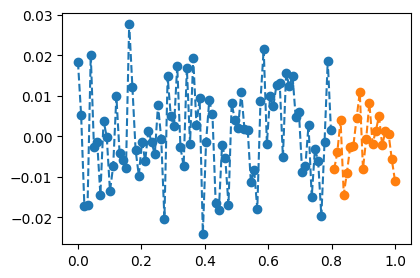

In [ ]:
torch.manual_seed(5)
Xall = torch.linspace(0,1,100).reshape(100,1)
Yall = Xall*0 + torch.randn(100).reshape(100,1)*0.01
X = Xall[:80,:]
Y = Yall[:80,:]
XX = Xall[80:,:]
YY = Yall[80:,:]
plt.plot(X,Y,'--o')
plt.plot(XX,YY,'--o')

`-` 학습: 이전의 그 네트워크를 학습, 그런데 수정된건 dropout layer추가

In [ ]:
torch.manual_seed(1)
net = torch.nn.Sequential(
    torch.nn.Linear(1,512),
    torch.nn.ReLU(),
    torch.nn.Dropout(0.8), # 이 레이어는 독특하게 학습할때 역할과 예측할때 역할이 다름.
    torch.nn.Linear(512,1)
)
loss_fn = torch.nn.MSELoss()
optimizer = torch.optim.Adam(net.parameters())
#---#
for epoch in range(1000):
    # step1
    Yhat = net(X) # 이때 net는 학습을하고있음.
    # step2
    loss = loss_fn(Yhat,Y)
    # step3
    loss.backward()
    # step4
    optimizer.step()
    optimizer.zero_grad()

`-` 결과시각화 (잘못된사용)

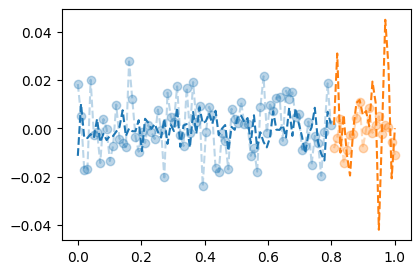

In [ ]:
plt.plot(X,Y,'--o',color="C0",alpha=0.3)
plt.plot(X,net(X).data,'--',color="C0") # 이때 net은 예측을 하고 있음. (그래서 이 net의 성능이 평가받고있음)
plt.plot(XX,YY,'--o',color="C1",alpha=0.3)
plt.plot(XX,net(XX).data,'--',color="C1") # 이때 net은 예측을 하고 있음. (그래스 이 net의 성능이 평가받고있음)

`-` 결과시각화 (올바른사용)

In [ ]:
net.training

True

- `net`에 저장된 attribute중 training이 있는데 이것이 True로 저장되어있음.
- `net`가 학습모드라는 의미

In [ ]:
net.eval() # net가 이제 train의 역할을 하지 않고 evaluation의 역할을 하도록

Sequential(
  (0): Linear(in_features=1, out_features=512, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.8, inplace=False)
  (3): Linear(in_features=512, out_features=1, bias=True)
)

- 위의코드를 실행하면 net.training 이 False 로 전환

In [ ]:
net.training

False

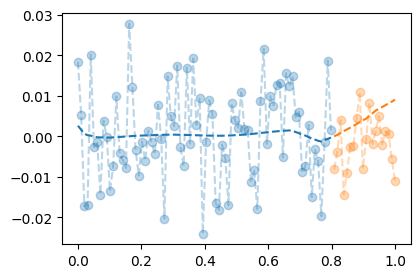

In [ ]:
plt.plot(X,Y,'--o',color="C0",alpha=0.3)
plt.plot(X,net(X).data,'--',color="C0") # 이때 net은 예측(평가)을 하고 있음
plt.plot(XX,YY,'--o',color="C1",alpha=0.3)
plt.plot(XX,net(XX).data,'--',color="C1") # 이때 net은 예측(평가)을 하고 있음.

- 드랍아웃레이어를 넣었을 뿐인데, 오버피팅이슈가 완화되었다!

## B. 드랍아웃 레이어

`-` 드랍아웃레이어의 동작을 알아보기 위해서 아래와 같이 텐서 `u`와 드랍아웃변환 `d`를 준비하자.

In [ ]:
u = torch.randn(10,2)
d = torch.nn.Dropout(0.9)

In [ ]:
u

tensor([[ 1.4645,  2.2101],
        [-1.0409,  0.3758],
        [ 1.5496,  1.2014],
        [ 1.1330,  0.8001],
        [ 0.2863,  0.0025],
        [-0.0217, -0.0475],
        [-0.5838,  1.6023],
        [-1.1729, -0.9439],
        [-0.8806,  0.9566],
        [-0.4359,  0.5812]])

In [ ]:
d(u)

tensor([[  0.0000,   0.0000],
        [-10.4094,   0.0000],
        [  0.0000,   0.0000],
        [  0.0000,   0.0000],
        [  0.0000,   0.0000],
        [ -0.0000,  -0.0000],
        [ -0.0000,   0.0000],
        [ -0.0000,  -0.0000],
        [ -0.0000,   0.0000],
        [ -4.3594,   0.0000]])

- 90%드랍아웃: 입력 중 임의로 90%를 골라서 0으로 만든다 + 10%이 확률로 살아남은 숫자는 10배만큼 값이 커진다.  
- 80%드랍아웃: 입력 중 임의로 80%를 골라서 0으로 만든다 + 20%이 확률로 살아남은 숫자는 5배만큼 값이 커진다.  
- 50%드랍아웃: 입력 중 임의로 50%를 골라서 0으로 만든다 + 50%이 확률로 살아남은 숫자는 2배만큼 값이 커진다.  

`-` 드랍아웃레이어의 성질: `net.train()`, `net.eval()` 로 dropout layer를 on/off 할 수 있다.

In [ ]:
u = torch.randn(10,2)
u

tensor([[-0.9490,  0.8282],
        [-0.4990,  0.6322],
        [ 0.3571,  0.0601],
        [ 0.1919, -0.4767],
        [-1.2675, -0.7150],
        [-2.0703, -0.7793],
        [ 0.8351, -1.3805],
        [-0.9620,  1.3993],
        [ 0.4413, -0.4300],
        [-0.7794, -0.3061]])

In [ ]:
net = torch.nn.Sequential(
    torch.nn.Dropout(0.9)
)
net

Sequential(
  (0): Dropout(p=0.9, inplace=False)
)

In [ ]:
u,net(u)

(tensor([[-0.9490,  0.8282],
         [-0.4990,  0.6322],
         [ 0.3571,  0.0601],
         [ 0.1919, -0.4767],
         [-1.2675, -0.7150],
         [-2.0703, -0.7793],
         [ 0.8351, -1.3805],
         [-0.9620,  1.3993],
         [ 0.4413, -0.4300],
         [-0.7794, -0.3061]]),
 tensor([[-0.0000,  0.0000],
         [-0.0000,  0.0000],
         [ 0.0000,  0.0000],
         [ 1.9190, -0.0000],
         [-0.0000, -0.0000],
         [-0.0000, -0.0000],
         [ 0.0000, -0.0000],
         [-0.0000, 13.9925],
         [ 0.0000, -0.0000],
         [-7.7937, -0.0000]]))

In [ ]:
net.training

True

In [ ]:
net.eval() # net.training 이 False

Sequential(
  (0): Dropout(p=0.9, inplace=False)
)

In [ ]:
u,net(u)

(tensor([[-0.9490,  0.8282],
         [-0.4990,  0.6322],
         [ 0.3571,  0.0601],
         [ 0.1919, -0.4767],
         [-1.2675, -0.7150],
         [-2.0703, -0.7793],
         [ 0.8351, -1.3805],
         [-0.9620,  1.3993],
         [ 0.4413, -0.4300],
         [-0.7794, -0.3061]]),
 tensor([[-0.9490,  0.8282],
         [-0.4990,  0.6322],
         [ 0.3571,  0.0601],
         [ 0.1919, -0.4767],
         [-1.2675, -0.7150],
         [-2.0703, -0.7793],
         [ 0.8351, -1.3805],
         [-0.9620,  1.3993],
         [ 0.4413, -0.4300],
         [-0.7794, -0.3061]]))

`-` 드랍아웃레이어의 정리

- 계산: (1) 입력의 일부를 임의로 0으로 만드는 역할 (2) 0이 안된것들은 스칼라배함
- on/off: net.train()을 사용하여 dropout layer를 활성화 할 수 있고, net.eval()을 사용하여 dropout layer를 비활성화 할수도 있다. (보통 학습/훈련의 경우는 dropout layer를 활성화하고, 예측/평가의 경우는 dropout layer를 비활성화한다)

`-` 이해 (1번제외하고는 시험X)


1. 드랍아웃 layer를 추가하니 어떠한 신비한 현상으로 오버피팅이 억제되는 효과가 있다는 것을 실험적으로 관찰하였다.
2. 드랍아웃은 학습을 방해하는 느낌을 준다. 그래서 학습이 오히려 잘 안되게 한다. 그래서 training에서 잘 못맞추게 만들어서 오버피팅을 막는다.
3. 랜덤으로 0이 되다보니까 학습할때 ${\bf Y} \approx \hat{\bf Y}$이 되도록 만들 수 있는 몇개의 특징적인 기술 위주로 학습하지 않고 전체적인 특징을 골고루 보게 된다.
4. 사실 랜덤포레스트 아이디어랑 같음.

## C. 드랍아웃 레이어의 위치

`-` ReLU, dropout의 특이한 성질: $\text{dropout}(\text{relu}({\bf X}))=\text{relu}(\text{dropout}({\bf X}))$

In [ ]:
u = torch.randn(10,2)
r = torch.nn.ReLU()
d = torch.nn.Dropout()

In [ ]:
torch.manual_seed(0)
r(d(u))

tensor([[-0.0000, -0.0000],
        [4.0484, -0.0000],
        [0.0000, 0.0000],
        [0.4972, 0.0000],
        [-0.0000, 0.0000],
        [0.0000, 0.0000],
        [0.8571, 0.0000],
        [0.0000, 3.2206],
        [0.0000, 0.0000],
        [-0.0000, -0.0000]])

In [ ]:
torch.manual_seed(0)
d(r(u))

tensor([[0.0000, 0.0000],
        [4.0484, 0.0000],
        [0.0000, 0.0000],
        [0.4972, 0.0000],
        [0.0000, 0.0000],
        [0.0000, 0.0000],
        [0.8571, 0.0000],
        [0.0000, 3.2206],
        [0.0000, 0.0000],
        [0.0000, 0.0000]])

`-` 다른 활성화함수는 성립안함.

In [ ]:
u = torch.randn(10,2)
s = torch.nn.Sigmoid()
d = torch.nn.Dropout()

In [ ]:
torch.manual_seed(0)
s(d(u))

tensor([[0.5000, 0.5000],
        [0.7550, 0.5000],
        [0.5000, 0.5000],
        [0.7339, 0.2347],
        [0.5000, 0.8629],
        [0.9022, 0.9295],
        [0.0478, 0.5000],
        [0.7091, 0.9340],
        [0.0370, 0.2498],
        [0.5000, 0.5000]])

In [ ]:
torch.manual_seed(0)
d(s(u))

tensor([[0.0000, 0.0000],
        [1.2742, 0.0000],
        [0.0000, 0.0000],
        [1.2484, 0.7128],
        [0.0000, 1.4301],
        [1.5046, 1.5683],
        [0.3661, 0.0000],
        [1.2191, 1.5801],
        [0.3278, 0.7318],
        [0.0000, 0.0000]])

`-` 드랍아웃 레이어는 아래와 같이 활성화함수 뒤에 위치해야함.

```Python
net = torch.nn.Sequential(
    torch.nn.Linear(1,512),
    torch.nn.ReLU(),
    torch.nn.Dropout(0.8),
    torch.nn.Linear(512,1)
)
```



`-` 그런데 활성화함수가 렐루일 경우에는 아래와 같이 드랍아웃과 렐루의 위치를 바꿔도 상관없다.

```Python
net = torch.nn.Sequential(
    torch.nn.Linear(1,512),
    torch.nn.Dropout(0.8),
    torch.nn.ReLU(),
    torch.nn.Linear(512,1)
)
```

- 심지어 보통 네트워크는 위와 같은 형태가 많음. (왜냐하면 계산효율이 더 좋음)